# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [1]:
#Link to Data Set https://www.kaggle.com/datasets/cedricaubin/linkedin-data-analyst-jobs-listings/data?select=linkedin-jobs-usa.csv

import pandas as pd
#Import pandas to allow me to load the CSV file into a dataframe and for data manipulation and analysis 

import numpy as np
#Import numpy in case I need to use mathematical operations 

df = pd.read_csv("data/linkedin-jobs-usa.csv")
df.head()
#Load the dataset and use df.head() to review the first few rows of the dataset 

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link
0,Data Analyst - Recent Graduate,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,Buffalo-Niagara Falls Area,"[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-22,https://www.linkedin.com/jobs/view/data-analys...
1,Data Analyst - Recent Graduate,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,"San Jose, CA","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-22,https://www.linkedin.com/jobs/view/data-analys...
2,Data Analyst,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,"Texas, United States","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...
3,Data Analyst,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,"Illinois, United States","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...
4,Entry-Level Data Analyst,The Federal Savings Bank,"The Federal Savings Bank, a national bank and ...",onsite,NaN,"Chicago, IL","[{'Seniority level': 'Entry level'}, {'Employm...",2022-11-17,https://www.linkedin.com/jobs/view/entry-level...


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [3]:
#Find out how many job titles exist in the data frame, as well as a list of each unique job title 
#There are 70 unique job titles. 
df['title'].nunique()
df['title'].unique()

#Check for salary range of all jobs listed
#Discovered this dataset has NaN value entered for salary for every line, unfortunately 
df['salary'].unique()

#See how many of the jobs listed are onsite, versus remote
#Returned onsite_remote column: remote 970, onsite 950, hybrid 925

df['onsite_remote'].value_counts()

#review how many, if any, jobs include the word "junior" or "entry level"
#Use case=False to account for differences in capitilization 

entry_level_jobs = df[
    df['title'].str.contains('entry', case=False)
]['title']

junior_jobs = df[
    df['title'].str.contains('junior', case=False)
]['title']

#Display jobs that iclude "Entry" in the title
entry_level_jobs.unique()

#Display jobs that iclude "Junior" in the title
junior_jobs.unique()

#Retrieve count of jobs that have entry or junior in the title
entry_level_jobs.count(), junior_jobs.count()

#Display jobs that are located in St. Louis
df['location'].str.contains('st. louis|st louis|saint louis', case=False)

#Broaden search to MO/Missouri as no results for St. Louis 
mo_jobs = df[
    df['location'].str.contains('missouri|mo', case=False)
]

#View the number of jobs based in Missouri 
mo_jobs.shape[0]

entry_level_jobs.unique()


array(['Entry-Level Data Analyst', 'Entry Level Data Analyst',
       'Data Analyst I (entry level)', 'Junior Data Analyst-Entry Level'],
      dtype=object)

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

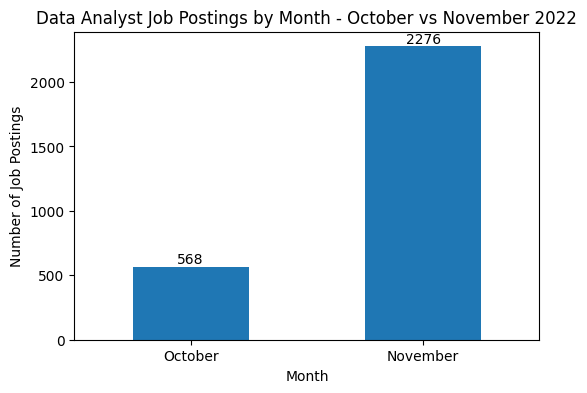

In [4]:
#Import matplotlib to have tools to create viz

import matplotlib.pyplot as plt

#The viz should identify the number of jobs posted in Oct versus Nov (the two months this dataset reflects)

#I'll be using the months the jobs were posted in my viz, so I want to make sure they are in datetime format 
df['posted_date'] = pd.to_datetime(df['posted_date'])

#I believe only Oct and Nov exist in this dataset, but I want to double check
#Results: There is one post from August, which I will be excluding since it is an outlier 
df['posted_date'].dt.month_name().value_counts()

#I want to create a month column so I can use months in my visualization.  I need to change the "posted_date" column to datetime in order 
#use the code I'm working with 
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')

#Creation of month column to pull individual months for viz
df['month'] = df['posted_date'].dt.month_name()

#Count jobs by individual month (excluding the 1 outlier from August)
monthly_counts = df['month'].value_counts().reindex(['October', 'November'])

#Check to make sure montly_counts works correctly 
monthly_counts

#Create a bar chart comparing count of job postings in Oct vs Nov 
plt.figure(figsize=(6,4))
bars = monthly_counts.plot(kind='bar')

plt.title('Data Analyst Job Postings by Month - October vs November 2022')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=0)

#The number isn't clear so I want to add value labels 
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() /2, 
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.show()

Text(0, 0.5, 'Number of Jobs Listed')

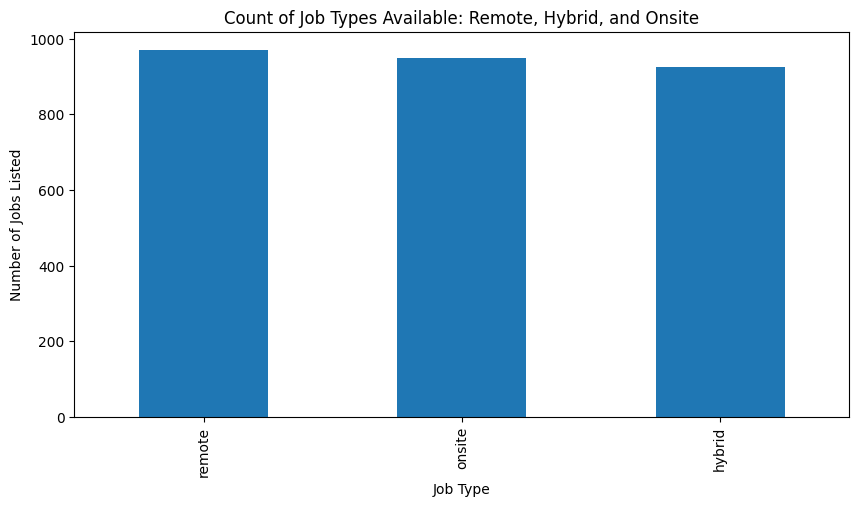

In [5]:
#Import matplotlib to have tools to create viz

import matplotlib.pyplot as plt

#I originally wanted to show the differences in number of jobs between onsite, remote, and hybrid type, but the results are all very close and
#it makes for an uninteresting graph, so I also included month by month job post above. 
#Create variable job_type_counts to store code for job counts
job_type_counts = df['onsite_remote'].value_counts()

#Create a bar graph that shows the number of onsite, versus remote, versus hybrid jobs available 
# at the time the dataset was collected
plt.figure(figsize=(10, 5))
job_type_counts.plot(kind='bar')

#Add graph title and labels to x and y axis
plt.title('Count of Job Types Available: Remote, Hybrid, and Onsite')
plt.xlabel('Job Type')
plt.ylabel('Number of Jobs Listed')

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
2. Do you have any concerns about your dataset? 
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

#1.The date range of this dataset is smaller than I realized. The scope of my project is to
#see how frequently jobs with Data Analysis in the title are published to LinkedIn based on
#historical data.  I have a much smaller sample size than anticipated
#I was also surprised (but having been on the job hunt for a few months not entirely surprised) that
#this data set did not have any jobs listed for St. Louis
#2. I'm concerned that the majority of the posts have "NaN" for salary, but I can see a salary range written 
# in the job description.  I'm uncertain why that salary range wouldn't pull properly from all JDs (instead of just a few), 
#causing me to question the datasets cleanliness
# Too small a sample size to draw any solid conclusions from 
#There is one job posted from Aug in this dataset, zero from Sept, 568 from Oct, and 2276 for Nov.  I'm wondering if the creator of this dataset
# pulled everything in Nov, giving Nov a much higher number of posts, as previous months likelky had expired  
# 3.  I need to format the city/state so they are all in the same format. Some show city and State, while others just show state, USA. 